In [ ]:
# Cell 1: Setup Environment
import os
from google.colab import drive

# Mount Google Drive to access and save datasets/outputs
drive.mount('/content/drive')

# Install dependencies
!pip install -q fastmri h5py matplotlib numpy tqdm requests runstats

# Clone the repositories if they don't exist
if not os.path.exists('/content/fastMRI'):
    !git clone https://github.com/facebookresearch/fastMRI.git

if not os.path.exists('/content/M4Raw'):
    !git clone https://github.com/mylyu/m4raw.git M4Raw

# Add fastMRI to Python path
import sys
sys.path.append('/content/fastMRI')

print("Environment setup complete! Repositories cloned.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.0 MB/s eta 0:00:00
Cloning into 'fastMRI'...
remote: Enumerating objects: 1884, done.
remote: Counting objects: 100% (588/588), done.
remote: Compressing objects: 100% (197/197), done.
remote: Total 1884 (delta 470), reused 391 (delta 391), pack-reused 1296 (from 1)
Receiving objects: 100% (1884/1884), 1.38 MiB | 18.07 MiB/s, done.
Resolving deltas: 100% (1174/1174), done.
Cloning into 'M4Raw'...
remote: Enumerating objects: 235, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 235 (delta 103), reused 131 (delta 55), pack-reused 25 (from 1)
Receiving obje

In [ ]:
# Cell 2: Data Processing and Masking
import h5py
import numpy as np
import matplotlib.pyplot as plt
from fastmri.data import transforms as T
from fastmri.data.subsample import RandomMaskFunc
import torch
import fastmri
import os

# Define paths - Updated to use an existing file found in Drive
M4RAW_SAMPLE_PATH = '/content/drive/MyDrive/T1_Test_Data/Copy of 2022061003_T101.h5'

# Create an undersampling mask (simulate 4x acceleration/low quality)
mask_func = RandomMaskFunc(center_fractions=[0.08], accelerations=[4])

def process_mri_slice(file_path, slice_idx=15):
    with h5py.File(file_path, 'r') as f:
        # Assuming standard fastMRI/M4Raw h5 structure
        kspace = f['kspace'][slice_idx]
        target = f['reconstruction_rss'][slice_idx] if 'reconstruction_rss' in f else None

    # Convert to fastmri tensor
    kspace_tensor = T.to_tensor(kspace)

    # Apply mask to simulate noisy/low-quality acquisition
    masked_kspace, mask, _ = T.apply_mask(kspace_tensor, mask_func)

    # Create the zero-filled reconstruction (The "Noisy/Aliased" intermediate state)
    sampled_image = fastmri.ifft2c(masked_kspace)
    sampled_image_abs = fastmri.complex_abs(sampled_image)

    # Combine coils if it's multi-coil data
    if len(sampled_image_abs.shape) > 2:
        zero_filled = fastmri.rss(sampled_image_abs, dim=0)
    else:
        zero_filled = sampled_image_abs

    return kspace_tensor, masked_kspace, zero_filled, target

# Note: Only execute the function if a file is present
if os.path.exists(M4RAW_SAMPLE_PATH):
    orig_kspace, masked_kspace, zero_filled, target = process_mri_slice(M4RAW_SAMPLE_PATH)
    print(f"Data successfully loaded from {M4RAW_SAMPLE_PATH} and masked to simulate low-field acquisition.")
else:
    print(f"Please ensure you have placed an M4Raw .h5 file at {M4RAW_SAMPLE_PATH}")

Data successfully loaded from /content/drive/MyDrive/T1_Test_Data/Copy of 2022061003_T101.h5 and masked to simulate low-field acquisition.


In [ ]:
# Cell 3a: Patch the VarNet inference script to generate masks on the fly
import os

varnet_script_path = '/content/fastMRI/fastmri_examples/varnet/run_pretrained_varnet_inference.py'

if os.path.exists(varnet_script_path):
    with open(varnet_script_path, 'r') as f:
        script_content = f.read()

    # Find the line where the transform is initialized
    target_line = "data_transform = T.VarNetDataTransform()"

    # Replace it with code that includes a random undersampling mask
    replacement_code = """from fastmri.data.subsample import RandomMaskFunc
    mask_func = RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
    data_transform = T.VarNetDataTransform(mask_func=mask_func)"""

    if target_line in script_content:
        script_content = script_content.replace(target_line, replacement_code)

        with open(varnet_script_path, 'w') as f:
            f.write(script_content)
        print("Successfully patched VarNet inference script to handle M4Raw data!")
    else:
        print("Script already patched or target line not found.")
else:
    print(f"Could not find {varnet_script_path}. Ensure fastMRI is cloned properly.")

Successfully patched VarNet inference script to handle M4Raw data!


In [ ]:
# Cell 3: Execute Deep Learning Inference (with checkpoint cleaning)
import os
import torch

# Define Directories
INPUT_DIR = '/content/drive/MyDrive/T1_Test_Data'
UNET_OUT_DIR = '/content/drive/MyDrive/T1_Outputs_UNet'
VARNET_OUT_DIR = '/content/drive/MyDrive/T1_Outputs_VarNet'
WEIGHTS_DIR = '/content/drive/MyDrive/fastMRI_Weights'

os.makedirs(UNET_OUT_DIR, exist_ok=True)
os.makedirs(VARNET_OUT_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Define paths for the weights
UNET_WEIGHTS = os.path.join(WEIGHTS_DIR, 'unet_brain_mc.pt')
M4RAW_LIGHTNING_CKPT = '/content/drive/MyDrive/M4Raw_PI_VarNet.ckpt'
CLEAN_VARNET_WEIGHTS = os.path.join(WEIGHTS_DIR, 'm4raw_varnet_clean.pt')

# Step 3a: Download U-Net weights if they don't already exist
if not os.path.exists(UNET_WEIGHTS):
    print("Downloading U-Net weights...")
    !wget -q -O "{UNET_WEIGHTS}" https://dl.fbaipublicfiles.com/fastMRI/trained_models/unet/brain_leaderboard_state_dict.pt

# Step 3b: Clean VarNet Checkpoint if necessary
if os.path.exists(M4RAW_LIGHTNING_CKPT):
    print("Unpacking and filtering PyTorch Lightning checkpoint for VarNet...")
    ckpt = torch.load(M4RAW_LIGHTNING_CKPT, map_location='cpu')
    state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt

    clean_dict = {}
    for k, v in state_dict.items():
        # Remove known Lightning prefixes
        new_key = k.replace('varnet.', '', 1) if k.startswith('varnet.') else k.replace('model.', '', 1) if k.startswith('model.') else k
        # Skip loss-related parameters that cause load errors
        if new_key == 'loss.w':
            continue
        clean_dict[new_key] = v

    torch.save(clean_dict, CLEAN_VARNET_WEIGHTS)
    print(f"Cleaned weights saved to {CLEAN_VARNET_WEIGHTS}")

# Step 3c: Run Pretrained U-Net
print("\nRunning U-Net Enhancement...")
!python /content/fastMRI/fastmri_examples/unet/run_pretrained_unet_inference.py \
    --challenge unet_brain_mc \
    --data_path "{INPUT_DIR}" \
    --output_path "{UNET_OUT_DIR}" \
    --state_dict_file "{UNET_WEIGHTS}"

# Step 3d: Run VarNet using Cleaned weights
if os.path.exists(CLEAN_VARNET_WEIGHTS):
    print("\nRunning VarNet Enhancement with Cleaned M4Raw Weights...")
    !python /content/fastMRI/fastmri_examples/varnet/run_pretrained_varnet_inference.py \
        --challenge varnet_brain_mc \
        --data_path "{INPUT_DIR}" \
        --output_path "{VARNET_OUT_DIR}" \
        --state_dict_file "{CLEAN_VARNET_WEIGHTS}"
else:
    print(f"Error: Missing weights at {CLEAN_VARNET_WEIGHTS}")

print("Inference Complete!")

Unpacking and filtering PyTorch Lightning checkpoint for VarNet...
Cleaned weights saved to /content/drive/MyDrive/fastMRI_Weights/m4raw_varnet_clean.pt

Running U-Net Enhancement...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Running inference:   0% 0/144 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that exc

/tmp/ipykernel_202/42427189.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(zero_filled), cmap='gray')


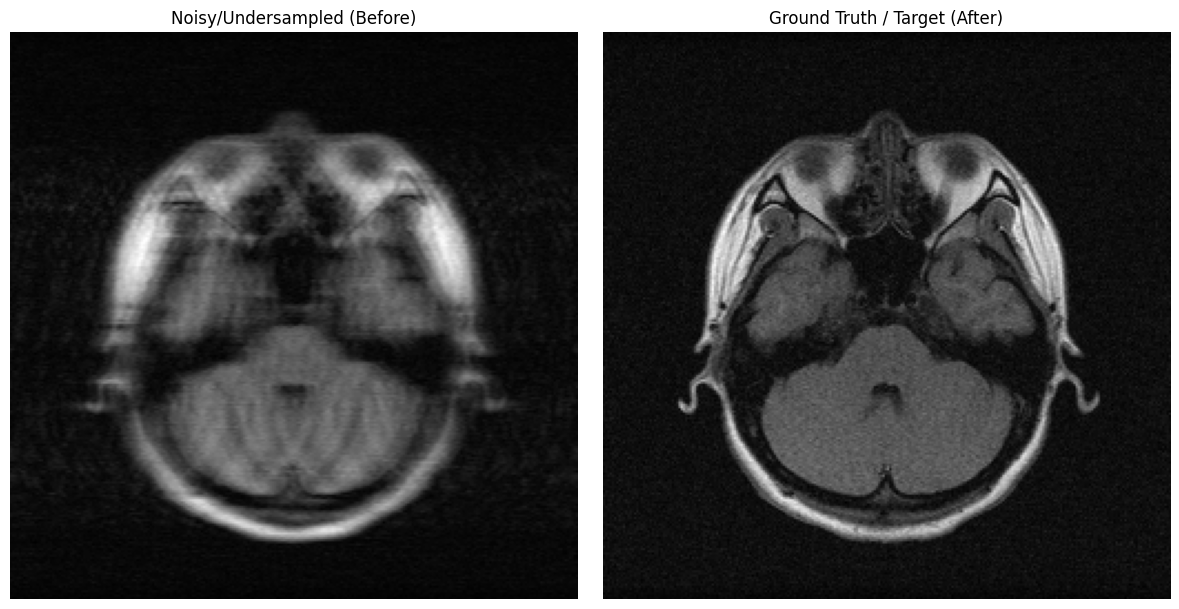

In [ ]:
# Cell 4: Visualization of Results
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(zero_filled, target):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Noisy/Undersampled (Before)")
    plt.imshow(np.abs(zero_filled), cmap='gray')
    plt.axis('off')

    if target is not None:
        plt.subplot(1, 2, 2)
        plt.title("Ground Truth / Target (After)")
        plt.imshow(np.abs(target), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if 'zero_filled' in globals():
    visualize_results(zero_filled, target)
else:
    print("No data available to visualize. Please run Cell 2.")

U-Net Output exists: True
VarNet Output exists: True


/tmp/ipykernel_202/2309893447.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(zero_filled), cmap='gray')


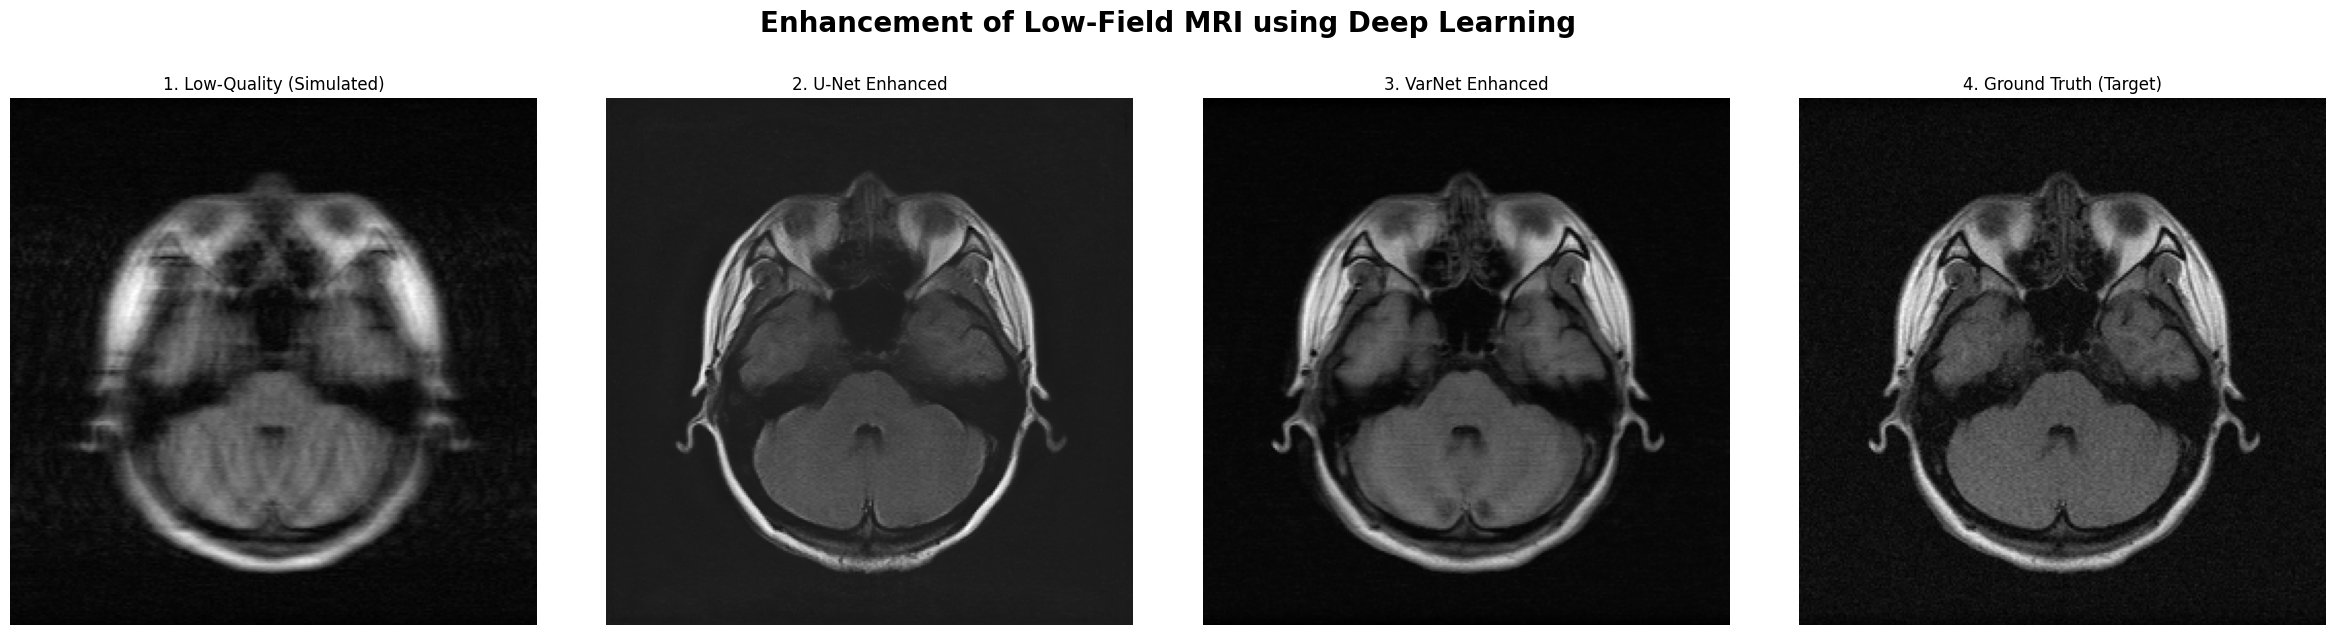

In [ ]:
# Cell 5: Final Comparison and Visualization (Including VarNet)
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths
unet_path = os.path.join(UNET_OUT_DIR, 'reconstructions', 'Copy of 2022061003_T101.h5')
varnet_path = os.path.join(VARNET_OUT_DIR, 'reconstructions', 'Copy of 2022061003_T101.h5')

# Check existence and print status
u_exists = os.path.exists(unet_path)
v_exists = os.path.exists(varnet_path)
print(f"U-Net Output exists: {u_exists}")
print(f"VarNet Output exists: {v_exists}")

if u_exists and v_exists:
    with h5py.File(unet_path, 'r') as f_unet, h5py.File(varnet_path, 'r') as f_varnet:
        # Load slice 15 to match the original simulation
        unet_recon = np.squeeze(f_unet['reconstruction'][15])
        varnet_recon = np.squeeze(f_varnet['reconstruction'][15])

    plt.figure(figsize=(24, 6))
    plt.suptitle("Enhancement of Low-Field MRI using Deep Learning", fontsize=20, fontweight='bold', y=1.05)

    plt.subplot(1, 4, 1)
    plt.title("1. Low-Quality (Simulated)")
    plt.imshow(np.abs(zero_filled), cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("2. U-Net Enhanced")
    plt.imshow(unet_recon, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("3. VarNet Enhanced")
    plt.imshow(varnet_recon, cmap='gray')
    plt.axis('off')

    if target is not None:
        plt.subplot(1, 4, 4)
        plt.title("4. Ground Truth (Target)")
        plt.imshow(np.abs(target), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Error: One or more reconstruction files are missing. Please re-run Cell 3.")